# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 9     |  |
| :-------------|:-------------|
| Edzard Inia | 6510983 |
| Floor van de Schaft| 6246648 |
| Pim van Beers | 6542026 |

## Opdracht 1: Planning.

| Planning Groep: 9     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 10:40 - 11:15 | Pim |
| Ontwerp-eis berekenen| 10:40 - 11:15  | Floor en Edzard|
| Schetsen massa-veer systeem (synthese) | 11:30-12:30 | hele groep |
| Simulatie (massa en veer checken) | 13:30 - 13:40 | hele groep |
| Eerste ontwerp bouwen (Fabricage) | 13:40 - 14:00 | hele groep |
| Mijlpaal 1 (eerste ontwerp) | 14:00 | ---|
| Mijlpaal 2 (uiteindelijke ontwerp en meting) | 14:30 | ---|
| Mijlpaal 3 (Beginnen met opruimen ) | 16:30 | ---|
| Pauze 1| 10:30 - 10:40  | hele groep |
| Pauze 2| 12:30 - 13:30 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 6 |
| hoe lang voor één meting | 5 minuten per meting |
| verwacht nauwkeurigheid meting | ~3.5% |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:
# Bereken hier je benodigde 

#bij het aanleggen van een trilling van 5 Hz zoeken we een kantelfrequentie die deze trilling dempt met een factor 3

Am = 1
Av = 3
f = 5

D = Am/Av
f0 = f/np.sqrt(1-D)
print(round(f0,1))

6.1


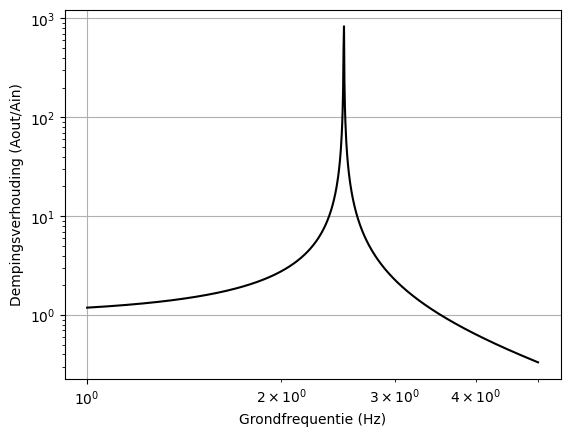

In [3]:
# Voeg hier je plot in.

f_grond = np.linspace(1,5, 1000)

def demping(f):
    return np.abs(1 / (1- (f/2.5)**2))

plt.plot(f_grond, demping(f_grond), 'k')
plt.grid()
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Dempingsverhouding (Aout/Ain)')
plt.xlabel('Grondfrequentie (Hz)')
plt.show()


In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.

g = 9.81
delta_x = g/(np.pi*2*f0)**2
print(delta_x)
print(f" delta_x = {delta_x*100: .2f} cm")

0.006626405410208892
 delta_x =  0.66 cm


## Opdracht 3: Plot de grafiek.

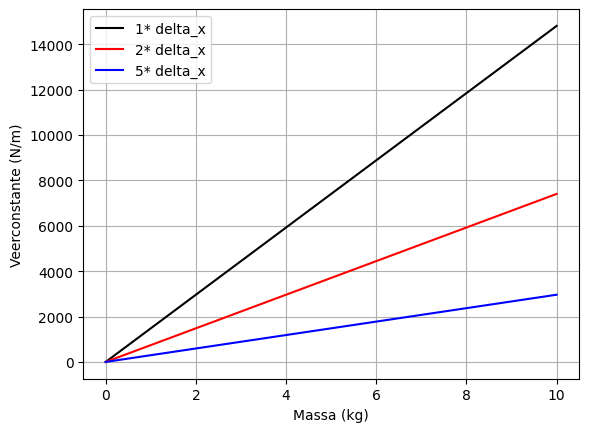

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

def veerconstante(m, del_x):
    return (g*m)/del_x

massa = np.linspace(0, 10, 1000)

plt.plot(massa, veerconstante(massa, delta_x), 'k', label = '1* delta_x')
plt.plot(massa, veerconstante(massa, delta_x*2), 'r', label = '2* delta_x')
plt.plot(massa, veerconstante(massa, delta_x*5),'b', label = '5* delta_x')
plt.xlabel('Massa (kg)')
plt.ylabel('Veerconstante (N/m)')
plt.legend()
plt.grid()
plt.show()

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- Verlaag veerconstante
- Verhoog massa

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 8cm 

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="5_1.jpeg" width="400">
<img src="5_4.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

**8.0 cm**

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

**Ja hij haalt 9.5cm**

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

**Hij zou ongeveer 20 cm verder kunnen uitktrekken**

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

**Ja dat kan in onze opstelling**

### Gaat je ontwerp dus voldoen aan de eis?

**Ja**

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

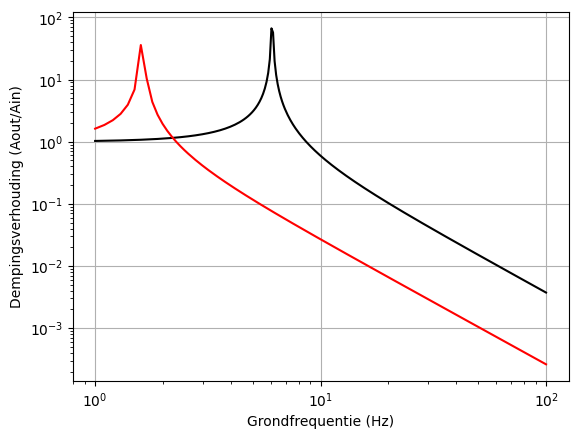

In [6]:
# Voeg hier je plot in.
delta_x = 0.095 #m
g = 9.81 
f_grond = np.linspace(1,100, 1000)

w0 = np.sqrt(g/delta_x)/ (2*np.pi)

def demping(f, w_0):
    return np.abs(1 / (1- (f/w_0)**2))

plt.plot(f_grond, demping(f_grond, 6.1), 'k')
plt.plot(f_grond, demping(f_grond, w0), 'r')
plt.grid()
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Dempingsverhouding (Aout/Ain)')
plt.xlabel('Grondfrequentie (Hz)')
plt.show()

## Opdracht 6 **Antwoorden na eerste iteratie**

**Voor meer stabiliteit is er gekozen voor een nieuwe opstelling, ook al werkte de vorige goed!**

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

**8.0 cm**

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

**Ja hij haalt 15 cm**

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

**Hij zou ongeveer 20 cm verder kunnen uitktrekken**

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

**Ja dat kan in onze opstelling**

### Gaat je ontwerp dus voldoen aan de eis?

**Ja**

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

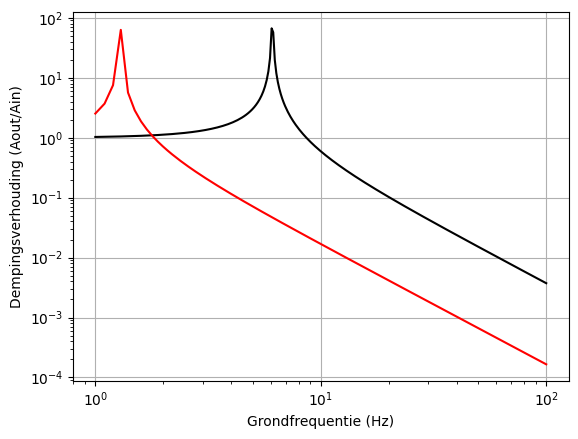

In [7]:
# Voeg hier je plot in.
# Dit is de nieuwe plot met de iteratie toegevoegd, de delta_x is is nu van 9,5 cm naar 15 cm gegaan
delta_x = 0.15 #m 
g = 9.81 
f_grond = np.linspace(1,100, 1000)

w0 = np.sqrt(g/delta_x)/ (2*np.pi)

def demping(f, w_0):
    return np.abs(1 / (1- (f/w_0)**2))

plt.plot(f_grond, demping(f_grond, 6.1), 'k')
plt.plot(f_grond, demping(f_grond, w0), 'r')
plt.grid()
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Dempingsverhouding (Aout/Ain)')
plt.xlabel('Grondfrequentie (Hz)')
plt.show()

#### Schets verbeterde opstelling
<img src="schets.jpeg" width="400">

## Opdracht 7: Plotten maar

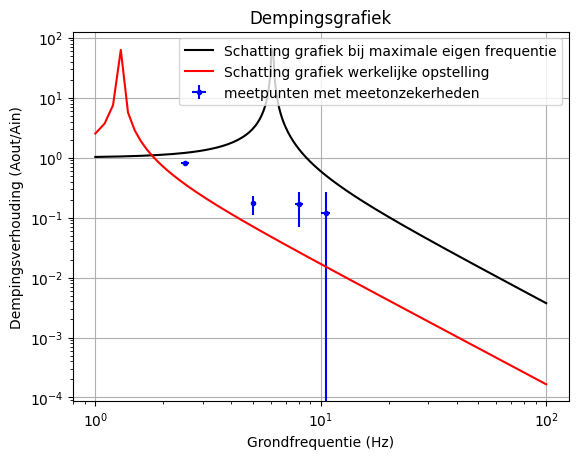

In [8]:
# Voeg hier je plots in.
frequentie = [2.5, 8, 10.5,5]
amplitude_verhouding = [0.8,0.17,0.12, 0.172]
f_fout = [0.1,0.3,0.5,0.1]
av_fout = [0.03,0.1,0.15,0.06]

plt.errorbar(frequentie,amplitude_verhouding,xerr = f_fout, yerr = av_fout, fmt = 'b.', label = 'meetpunten met meetonzekerheden')

# Voeg hier je plot in.
delta_x = 0.15 #m
g = 9.81 
f_grond = np.linspace(1,100, 1000)

w0 = np.sqrt(g/delta_x)/ (2*np.pi)

def demping(f, w_0):
    return np.abs(1 / (1- (f/w_0)**2))

plt.plot(f_grond, demping(f_grond, 6.1), 'k', label = 'Schatting grafiek bij maximale eigen frequentie')
plt.plot(f_grond, demping(f_grond, w0), 'r', label = 'Schatting grafiek werkelijke opstelling')
plt.grid()
plt.title('Dempingsgrafiek')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Dempingsverhouding (Aout/Ain)')
plt.xlabel('Grondfrequentie (Hz)')
plt.show()

## Discussie

We zien dat de meetpunten niet goed overeenkomen met de schattingsgrafiek. Dit is waarschijnlijk te verklaren door het feit dat wij gebruik hebben gemaakt van elastieken en die gedragen zich niet als ideale veren. Hierdoor zal het verband anders zijn.

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

**De onderstaande cellen horen bij het volgende leerdoel: Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een ontwerpruimte opspannen.**

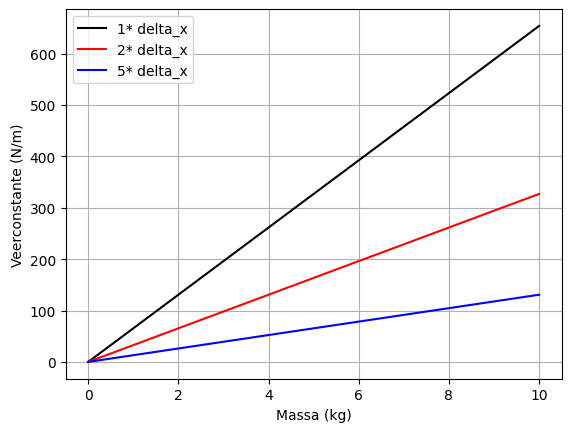

In [9]:
# Als je met Python je resultaten wil laten zien: voeg hier je code in.

# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().

def veerconstante(m, del_x):
    return (g*m)/del_x

massa = np.linspace(0, 10, 1000)

plt.plot(massa, veerconstante(massa, delta_x), 'k', label = '1* delta_x')
plt.plot(massa, veerconstante(massa, delta_x*2), 'r', label = '2* delta_x')
plt.plot(massa, veerconstante(massa, delta_x*5),'b', label = '5* delta_x')
plt.xlabel('Massa (kg)')
plt.ylabel('Veerconstante (N/m)')
plt.legend()
plt.grid()
plt.show()

We kunnen $\Delta x$ verhogen door:

- Verlaag veerconstante
- Verhoog massa

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 8cm 

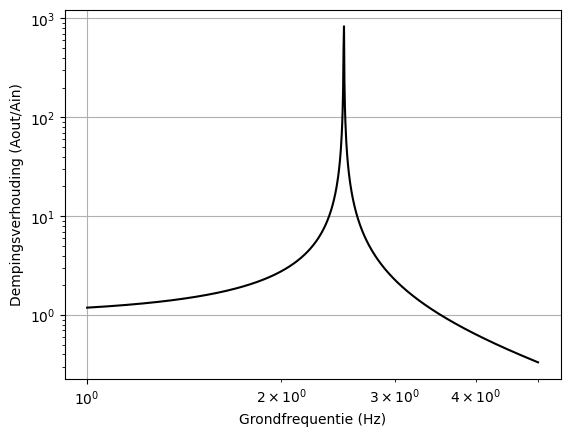

In [10]:
# Voeg hier je plot in.

f_grond = np.linspace(1,5, 1000)

def demping(f):
    return np.abs(1 / (1- (f/2.5)**2))

plt.plot(f_grond, demping(f_grond), 'k')
plt.grid()
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Dempingsverhouding (Aout/Ain)')
plt.xlabel('Grondfrequentie (Hz)')
plt.show()


**De onderstaande cellen betreffen het volgende leerdoel: Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp.**

##### schets opstelling: 
<img src="5_1.jpeg" width="400">
<img src="5_4.jpeg" width="400">

We kunnen $\Delta x$ verhogen door:

- Verlaag veerconstante
- Verhoog massa

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 8cm 

**Voor meer stabiliteit is er gekozen voor een nieuwe opstelling, ook al werkte de vorige goed!**

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

**8.0 cm**

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

**Ja hij haalt 15 cm**

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

**Hij zou ongeveer 20 cm verder kunnen uitktrekken**

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

**Ja dat kan in onze opstelling**

### Gaat je ontwerp dus voldoen aan de eis?

**Ja**

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

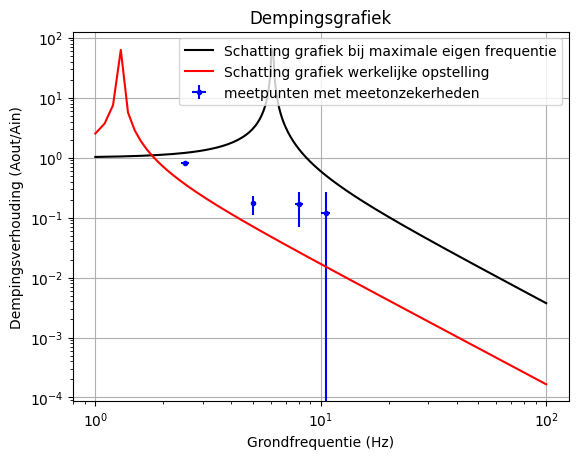

In [11]:
# Voeg hier je plots in.
frequentie = [2.5, 8, 10.5,5]
amplitude_verhouding = [0.8,0.17,0.12, 0.172]
f_fout = [0.1,0.3,0.5,0.1]
av_fout = [0.03,0.1,0.15,0.06]

plt.errorbar(frequentie,amplitude_verhouding,xerr = f_fout, yerr = av_fout, fmt = 'b.', label = 'meetpunten met meetonzekerheden')

# Voeg hier je plot in.
delta_x = 0.15 #m
g = 9.81 
f_grond = np.linspace(1,100, 1000)

w0 = np.sqrt(g/delta_x)/ (2*np.pi)

def demping(f, w_0):
    return np.abs(1 / (1- (f/w_0)**2))

plt.plot(f_grond, demping(f_grond, 6.1), 'k', label = 'Schatting grafiek bij maximale eigen frequentie')
plt.plot(f_grond, demping(f_grond, w0), 'r', label = 'Schatting grafiek werkelijke opstelling')
plt.grid()
plt.title('Dempingsgrafiek')
plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Dempingsverhouding (Aout/Ain)')
plt.xlabel('Grondfrequentie (Hz)')
plt.show()